# Pha R - Buoc 2: Huan luyen T_phi amortized

**Muc tieu:** train mot mang `T_phi` duy nhat tren toan bo corpus da cau hinh, roi dong bang lai.

**Thoi gian uoc tinh:** day la buoc TON THOI GIAN NHAT cua Pha R (hang chuc phut den vai gio tren CPU tuy cau hinh). Chay thu voi `max_epochs` nho truoc de uoc luong thoi gian, roi moi chay day du.

**Output:** `results/checkpoints/phi_amortized.pt` + loss curve.

Xem spec trong [`docs/PHASE_R_GUIDE.md`](../docs/PHASE_R_GUIDE.md) muc 4.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import yaml, time, numpy as np, torch
from pathlib import Path

from pqrst.data.synthetic.corpus import load_corpus
from pqrst.estimators.mine.amortized import train_amortized, AmortizedTrainConfig

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load(open(BASE/'configs'/'mine'/'amortized.yaml', encoding='utf-8'))
cfg

{'train': {'hidden_dims': [128, 128, 64],
  'learning_rate': 0.001,
  'windows_per_batch': 32,
  'max_epochs': 100,
  'patience': 15,
  'eval_n_shuffles': 20,
  'final_estimate_last_k_epochs': 10,
  'seed': 42},
 'eval': {'n_shuffles': 50}}

## 1. Nap corpus da sinh o notebook 01

In [2]:
train_windows = load_corpus(str(BASE / 'data' / 'interim' / 'synthetic_corpus' / 'train.npz'))
val_windows = load_corpus(str(BASE / 'data' / 'interim' / 'synthetic_corpus' / 'val.npz'))
print(f'Loaded train: {len(train_windows)}, val: {len(val_windows)}')


Loaded train: 22950, val: 4050


## 2. Chay thu nhanh de uoc luong thoi gian

**Luon chay o nay truoc** voi `max_epochs=2` de biet 1 epoch mat bao lau, truoc khi chay full.

In [3]:
config = AmortizedTrainConfig(**cfg['train'])
config.max_epochs = 2
start = time.time()
est, hist = train_amortized(train_windows, val_windows, config)
t_epoch = (time.time() - start) / 2
print(f'Time per epoch: {t_epoch:.2f}s')
print(f'Estimated full run time: {t_epoch * cfg["train"]["max_epochs"] / 60:.2f} minutes')


Time per epoch: 186.29s
Estimated full run time: 310.49 minutes


## 3. Huan luyen day du

In [4]:
config = AmortizedTrainConfig(**cfg['train'])
est, hist = train_amortized(train_windows, val_windows, config)


## 4. Ve loss curve va chan doan hoi tu

Kiem tra ky (bai hoc tu Pha Q): val loss co nhieu manh khong? Uoc luong cuoi phai la **trung binh k epoch cuoi**, khong phai best-of-all-epochs.

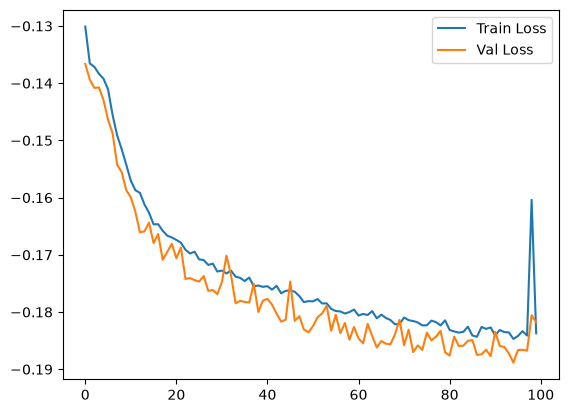

Val loss std dev in last 10 epochs: 0.00247


In [5]:
import matplotlib.pyplot as plt
plt.plot(hist['train_loss_history'], label='Train Loss')
plt.plot(hist['val_loss_history'], label='Val Loss')
plt.legend()
out_dir = BASE / 'results' / 'figures'
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / 'phase_r_amortized_training_loss.png')
plt.show()
val_std = np.std(hist['val_loss_history'][-config.final_estimate_last_k_epochs:])
print(f'Val loss std dev in last {config.final_estimate_last_k_epochs} epochs: {val_std:.5f}')


## 5. Luu checkpoint

In [8]:
from pqrst.estimators.mine.amortized import AmortizedTEEstimator
out_dir = BASE / 'results' / 'checkpoints'
out_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = out_dir / 'phi_amortized.pt'
est.save(str(checkpoint_path))

est_loaded = AmortizedTEEstimator.load(str(checkpoint_path))
w = val_windows[0]
# recreate raw x,y
x = np.zeros(w.n_samples + 1)
y = np.zeros(w.n_samples + 1)
x[:-1] = w.x_lag
y[:-1] = w.y_lag
y[1:] = w.y_t
te1 = est.estimate(x, y, seed=42)
te2 = est_loaded.estimate(x, y, seed=42)
assert np.isclose(te1, te2)
print('Checkpoint saved and verified.')


Checkpoint saved and verified.
